SETUP OR FETCH OUR ENV VARIABLE

In [74]:
import os


In [89]:
# Groq (model provider)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")


# search api key
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")

In [90]:
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq

#use groq llm

model = ChatGroq(
    temperature = 0.3,
    model="llama-3.1-8b-instant",
    

)

print("LLM initialized: ", model)

LLM initialized:  profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x00000208F3CA73D0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000208F3CA65D0> model_name='llama-3.1-8b-instant' temperature=0.3 model_kwargs={} groq_api_key=SecretStr('**********')


SEARCH functionality

In [77]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [78]:
tavily_search = TavilySearchResults(
    max_results=3,
    topic="general"
)

print(tavily_search)

max_results=3 api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'))


test Tavily search

In [79]:
tavily_search.invoke({'query': "Give me latest news about AI"})

[{'title': 'The latest AI news we announced in January',
  'url': 'https://blog.google/innovation-and-ai/products/google-ai-updates-january-2026/',
  'content': 'We opened access to our AI world model Genie 3. Project Genie — our experimental research prototype — is now open to Google AI Ultra subscribers (18+) in the U.S. Powered by Genie 3, it empowers users to create, explore and remix their own interactive worlds. Since its preview debut in August, the Genie 3 general-purpose world model has already enabled testers to uncover entirely new ways to design and explore digital environments. [...] ## Bullet points\n\n This article recaps Google\'s AI news from January, highlighting advancements in personal intelligence and various applications.\n Gemini app now connects to Google apps, offering personalized help; it\'s opt-in and available in beta.\n Gmail gets AI tools like "Help me write" for free; paid subscribers get advanced features like Proofread.\n Chrome\'s new features, powere

In [80]:
from langchain_community.utilities import GoogleSerperAPIWrapper

google_search = GoogleSerperAPIWrapper()

print(google_search)

k=10 gl='us' hl='en' type='search' result_key_for_type={'news': 'news', 'places': 'places', 'images': 'images', 'search': 'organic'} tbs=None serper_api_key='d5a647c51b90358ebfba2313f7b8ae94a28eb58e' aiosession=None


test google search

In [81]:
result = google_search.run("what places to visit in Dehradun?")
print(result)

Top Attractions in Dehradun ; 1. Forest Research Institute · 4.5. (705) ; 2. Tibetan Buddhist Temple · 4.5. (366) ; 3. Chetwoode Hall (Indian Military Academy). Dehradun is the capital of the Indian state of Uttarakhand, near the Himalayan foothills. It is a very famous tourist destination. You can go trekking on Old mussoorie Road and kimadi ('good spot' if I you know what i mean) also Assan barage bird sanctuary and benog wildlife sanctuary. Top 10 Best Places to Visit in Dehradun · 1. Tapkeshwar Temple – More Than Just a Temple · 2. Robber's Cave – Nature's Version of Hide & Seek. Discover the most popular places to visit in Dehradun · Gun Hill · Mussoorie Lake · Bhata Falls · Sahastradhara Natural Spring · Robber's Cave · Clock Tower · Malsi ... 38 Things to Do In Dehradun · 1. Robber's Cave · 2. Mindrolling Monastery · 3. Tapkeshwar Temple · 4. Sahastradhara Ropeway. Sahastradhara Ropeway. Top Things ... 5 places to visit in dehradun · 1.Shri Prakasheshwar Mahadev Mandir · 2. Paci

In [82]:
def tavily_search_tool(query: str) -> str:

    """
    search the web using tavily info, tips, attractions, etc.
    """
    #call the existing tavily search tool
    return tavily_search.invoke({"query": query})


def google_search_tool(query:str) -> str:

    """
    search the web using google serper for up to date travel information
    """
    return google_search.run(query)



In [83]:
tavily_search_tool("plan a trip to India")

[{'title': 'A First Timers Guide To Planning A Trip To India',
  'url': 'https://www.binnysfoodandtravel.com/2023/09/05/a-first-timers-guide-to-planning-a-trip-to-india/',
  'content': "To see Indian culture at its best and for a truly unforgettable experience, why not plan a trip to incredible India during one of the many fabulous and distinct festivals that are held throughout the year. They are a fantastic time to visit as each festival has a colourful story and various rituals attached to them.\n\n### Visas for India\n\nYou will require an Indian Visa to visit India, (with the exception of citizens of Bhutan and Nepal who do not need a visa). It is essential that you apply for your visa in advance before planning to travel to India.\n\nThe visa application process to enter India for a holiday is pretty simple and inexpensive. Around 113 nationalities can apply for an e-visa. [...] Top\n\nBinny's Food & Travel\n\nAn Award Winning Food, Travel & Wildlife Conservation Writer\n\n# A Fi

In [84]:
google_search_tool("Plan a 5 trip to India")

"This five-day tour includes the best of India's Golden Triangle (Delhi, Agra, and Jaipur), including the Taj Mahal, the Red Fort, Jaipur's City Palace, and lots ... We are planning for a 5-6 days trip but kinda not sure on which part of India we should explore. Mostly want to have a quiet time with small treks and good ... This India for beginners guide breaks down India trip planning, my top 5 fave trip routes in India and costs and prices in India. Discover the best of India from as little as $1,094. Choose from a wonderful selection of hotels, flights and rental cars to suit your travel style. You can ... India Golden Triangle Tour ... Many first-time visitors do a Golden Triangle tour, which visits the three cities of Delhi, Jaipur and Agra, to see the Taj Mahal. 1.Delhi. · 2.Agra. · 3.Rajasthan. · 4.Kullu-Manali/Nainital/Mussorie/Gangtok. · 5.Mumbai. · 6.Varanasi/Allahabad. · 7.Kerala. · 8.Darjeeling/Siliguri. A Beginner's Guide to Planning a Trip to India · Day 1: Dive into Delh

In [85]:
from langchain.agents import create_agent

system_prompt = """
You are a travel planner assistant. User asks travel queries like
'plan my trip to X', 'What to do in Y hotel', etc.
Always use the availabe web search tools(tavilySearch, GoogleSerperSearch)
to look up latest real-world travel info. Provide a helpful and clear itinerary/answer to the user.
"""


Travel planner agent ready!


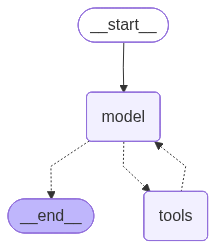

In [86]:
agent = create_agent(
    model = model,
    tools = [tavily_search_tool, google_search_tool],
    system_prompt=system_prompt.strip()

)

print("Travel planner agent ready!")
agent

Test time

In [91]:
response = agent.invoke({
    "message": [
        {"role": "user", "content": "plan a trip to India"}
    ]
})  # type: ignore


print("Agnet answer: \n")
print(response)

BadRequestError: Error code: 400 - {'error': {'message': '`tool calling` is not supported with this model', 'type': 'invalid_request_error', 'param': 'tool calling'}}

In [ ]:
response["messages"]

[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4s8mx206v', 'function': {'arguments': '{"query":"trip to X"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': 'hheck620r', 'function': {'arguments': '{"query":"latest travel information to X"}', 'name': 'google_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 363, 'total_tokens': 401, 'completion_time': 0.133537895, 'completion_tokens_details': None, 'prompt_time': 0.017630679, 'prompt_tokens_details': None, 'queue_time': 0.048148631, 'total_time': 0.151168574}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c84f4-0824-7270-b8bb-144af0c4f049-0', tool_calls=[{'name': 'tavily_search_tool', 'args': {'query': 'trip to X'}, 'id': '4s8mx206v', 'type': 'tool_call'}, {'name': 'google_search_tool', 'args

In [ ]:
final_answer = response["messages"][-1].content
print(final_answer)

Based on the search results, here's a helpful and clear itinerary for a trip to Santa Fe, New Mexico:

Day 1:

* Morning: Visit the Cathedral Basilica of St. Francis of Assisi and take a walking tour of the downtown area.
* Afternoon: Explore the art galleries and museums, such as the Georgia O'Keeffe Museum and the Museum of International Folk Art.
* Evening: Enjoy southwestern cuisine and browse the shops on Canyon Road.

Day 2:

* Morning: Visit the Meow Wolf Santa Fe and explore the interactive art exhibits.
* Afternoon: Take a culinary tour and sample some of the local flavors.
* Evening: Relax at the Four Seasons Resort Rancho Encantado Santa Fe or explore the nightlife in the downtown area.

Day 3:

* Morning: Visit the Petroglyph National Monument and explore the ancient rock carvings.
* Afternoon: Take a hike at the Kasha-Katuwe Tent Rocks National Monument or visit the Loretto Chapel.
* Evening: Enjoy a dinner at one of the local restaurants and reflect on the day's adventure